In [23]:
import logging

logger = logging.getLogger("ml_logger")  # Create a named logger
logger.setLevel(logging.INFO)

# Create a file handler
file_handler = logging.FileHandler('ml_program_detailed.log', mode='a')
file_handler.setLevel(logging.DEBUG)  # Set handler's minimum logging level

# Create a formatter and add it to the handler
formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
file_handler.setFormatter(formatter)

# Add the file handler to the logger
logger.addHandler(file_handler)

In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pylab as plt
import os
import PIL
from PIL import UnidentifiedImageError
pd.options.mode.chained_assignment = None

In [27]:
print('TensorFlow version: {}'.format(tf.__version__))
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found - On for CPU time!')
else:
    print('Found GPU at {}'.format(device_name))

TensorFlow version: 2.17.0
GPU device not found - On for CPU time!


In [29]:
def read_and_decode(filename, reshape_dims):
    # Read an image file to a tensor as a sequence of bytes
    image = tf.io.read_file(filename)
    # Convert the tensor to a 3D uint8 tensor
    image = tf.image.decode_jpeg(image, channels=IMG_CHANNELS)
    # Convert 3D uint8 tensor with values in [0, 1]
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image to the desired size
    return tf.image.resize(image, reshape_dims)

def show_image(filename):
    image = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
    plt.imshow(image.numpy());
    plt.axis('off');
    
def decode_csv(csv_row):
    record_defaults = ['Id', 'Weight']
    filename, pawpularity = tf.io.decode_csv(csv_row, record_defaults)
    pawpularity = tf.convert_to_tensor(float(pawpularity), dtype=tf.float32)
    image = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])
    return image, pawpularity

In [31]:
num_rows = 162
num_cols = 2
data = [[None] * num_cols] * num_rows  # Create a list of lists with None values
newdf = pd.DataFrame(data, columns = ['Id', 'Weight'])

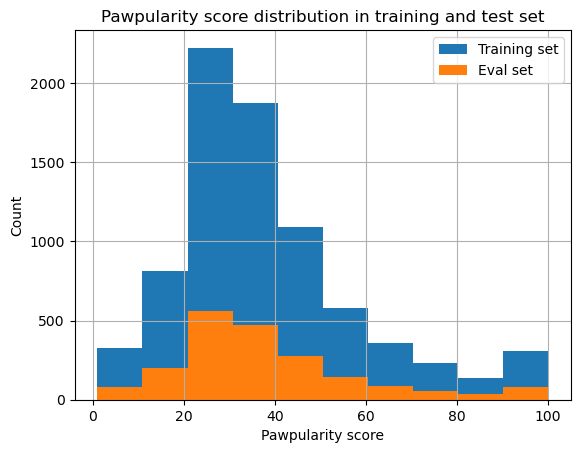

In [33]:
from sklearn.model_selection import StratifiedShuffleSplit

data_path = '/Users/wmeikle/Downloads/petfinder-pawpularity-score/'
data = pd.read_csv(data_path+'train.csv')

# Use stratified sampling
sssplit = StratifiedShuffleSplit(n_splits=1, test_size=0.2)
for train_index, test_index in sssplit.split(data, data['Pawpularity']):
    training_set = data.iloc[train_index]
    eval_set = data.iloc[test_index]
    
# Visually check distribution of pawpularity score in training and test sets
training_set['Pawpularity'].hist(label='Training set')
eval_set['Pawpularity'].hist(label='Eval set')
plt.title('Pawpularity score distribution in training and test set')
plt.xlabel('Pawpularity score')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.show()

# Export training and test sets as .csv files
training_set['Id'] = training_set['Id'].apply(lambda x: '/Users/wmeikle/Downloads/petfinder-pawpularity-score/train/'+x+'.jpg')
training_set[['Id', 'Pawpularity']].to_csv('training_set.csv', header=False, index=False)
eval_set['Id'] = eval_set['Id'].apply(lambda x: '/Users/wmeikle/Downloads/petfinder-pawpularity-score/train/'+x+'.jpg')
eval_set[['Id', 'Pawpularity']].to_csv('eval_set.csv', header=False, index=False)

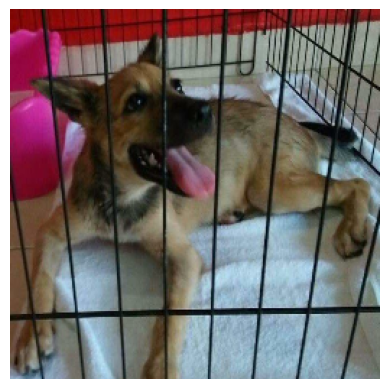

In [35]:
IMG_WIDTH = 256
IMG_HEIGHT = 256
IMG_CHANNELS = 3

path = '/Users/wmeikle/Downloads/petfinder-pawpularity-score/train/'
training_img = os.listdir(path)
rand_idx = np.random.randint(0, len(training_img)-1)
rand_img = training_img[rand_idx]

show_image(path+rand_img)

In [37]:
BATCH_SIZE = 256

train_dataset = tf.data.TextLineDataset(
    'training_set.csv').map(decode_csv).batch(BATCH_SIZE)

eval_dataset = tf.data.TextLineDataset(
    'eval_set.csv').map(decode_csv).batch(BATCH_SIZE)

).map(decode_csv).batch(BATCH_SIZE)

In [40]:
# Build model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=1, activation=None)
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        14,401 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,193 (63.25 KB)

 Trainable params: 16,193 (63.25 KB)

 Non-trainable params: 0 (0.00 B)

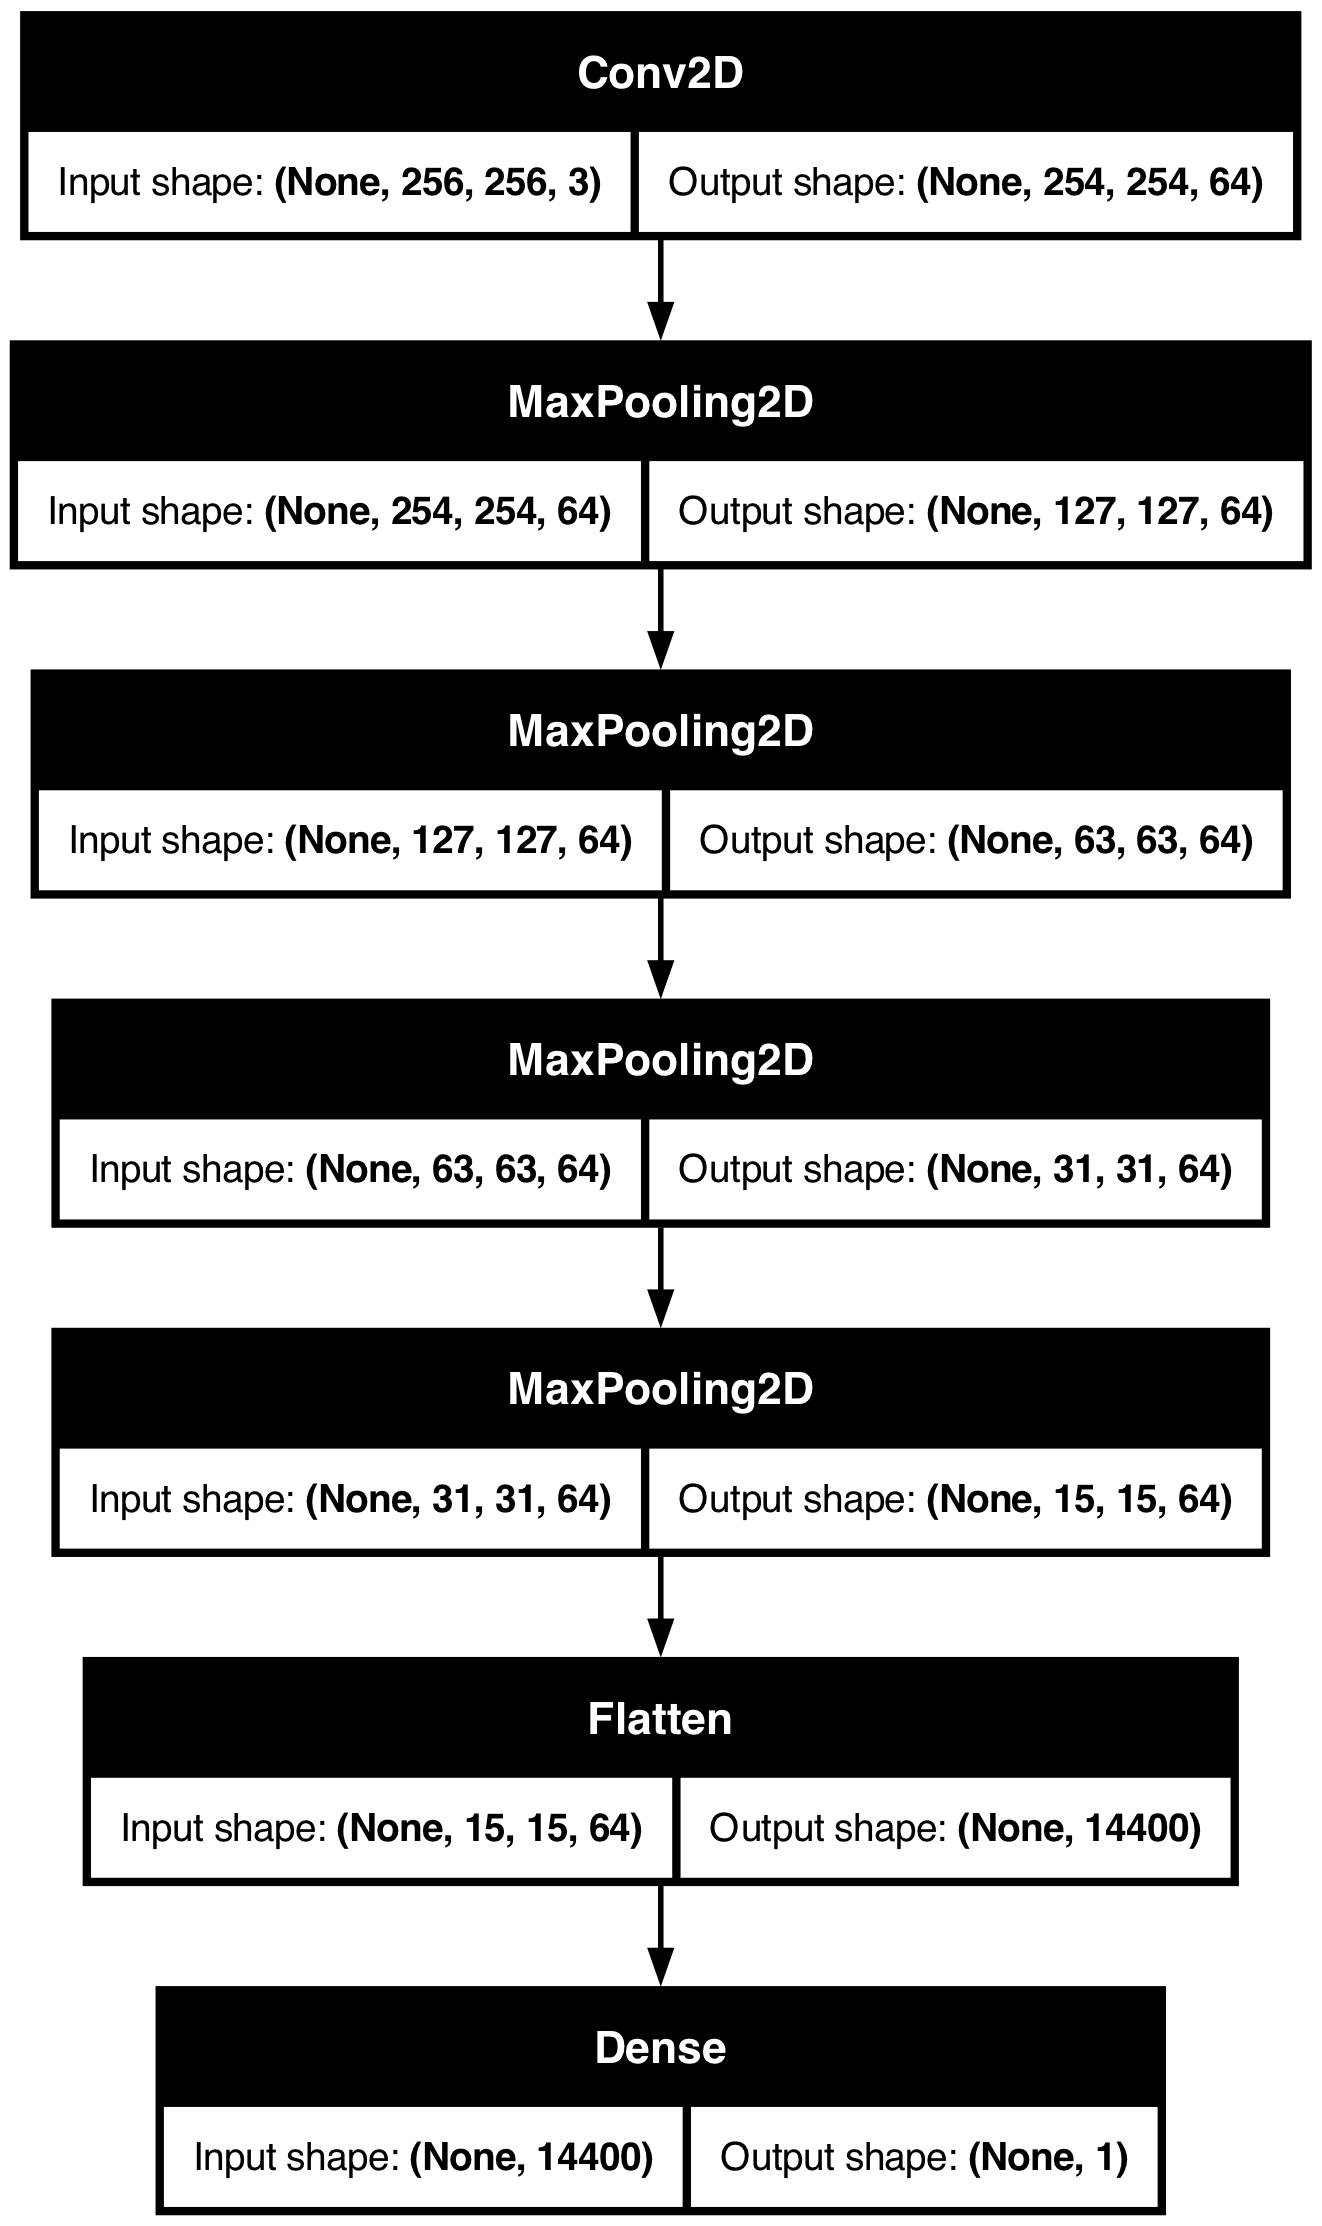

In [44]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=False)

In [45]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=[tf.keras.metrics.RootMeanSquaredError()])

In [48]:
%%time

history = model.fit(train_dataset, validation_data=eval_dataset, epochs=25, batch_size=BATCH_SIZE)

Epoch 1/25
     31/Unknown 185s 6s/step - loss: 1132.0109 - root_mean_squared_error: 33.3656

2025-09-12 20:38:16.413302: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 192s 6s/step - loss: 1121.2543 - root_mean_squared_error: 33.2000 - val_loss: 503.6735 - val_root_mean_squared_error: 22.4427
Epoch 2/25


2025-09-12 20:38:23.502492: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


31/31 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - loss: 456.9023 - root_mean_squared_error: 21.3733 - val_loss: 461.8120 - val_root_mean_squared_error: 21.4898
Epoch 3/25


...

31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - loss: 438.8521 - root_mean_squared_error: 20.9437 - val_loss: 454.6530 - val_root_mean_squared_error: 21.3226
Epoch 6/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 279s 9s/step - loss: 437.5313 - root_mean_squared_error: 20.9122 - val_loss: 452.7753 - val_root_mean_squared_error: 21.2785
Epoch 7/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 211s 7s/step - loss: 436.2456 - root_mean_squared_error: 20.8816 - val_loss: 451.1333 - val_root_mean_squared_error: 21.2399
Epoch 8/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 247s 8s/step - loss: 435.0994 - root_mean_squared_error: 20.8543 - val_loss: 449.9247 - val_root_mean_squared_error: 21.2114
Epoch 9/25


2025-09-12 21:04:43.438800: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


31/31 ━━━━━━━━━━━━━━━━━━━━ 233s 8s/step - loss: 434.0445 - root_mean_squared_error: 20.8293 - val_loss: 448.8562 - val_root_mean_squared_error: 21.1862
Epoch 10/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 2832s 94s/step - loss: 432.2922 - root_mean_squared_error: 20.7875 - val_loss: 446.2993 - val_root_mean_squared_error: 21.1258
Epoch 11/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 908s 30s/step - loss: 428.9113 - root_mean_squared_error: 20.7062 - val_loss: 440.8537 - val_root_mean_squared_error: 20.9965
Epoch 12/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 193s 6s/step - loss: 423.5455 - root_mean_squared_error: 20.5761 - val_loss: 434.9132 - val_root_mean_squared_error: 20.8546
Epoch 13/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 472s 15s/step - loss: 418.2906 - root_mean_squared_error: 20.4478 - val_loss: 431.1772 - val_root_mean_squared_error: 20.7648
Epoch 14/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 719s 24s/step - loss: 415.0791 - root_mean_squared_error: 20.3692 - val_loss: 428.2292 - val_root_mean_squared_error: 20.6937
Epoch 15/25
31/31 ━━━━━

2025-09-12 22:51:08.644543: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


31/31 ━━━━━━━━━━━━━━━━━━━━ 216s 7s/step - loss: 410.3322 - root_mean_squared_error: 20.2521 - val_loss: 423.6737 - val_root_mean_squared_error: 20.5833
Epoch 18/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 269s 9s/step - loss: 409.2513 - root_mean_squared_error: 20.2254 - val_loss: 423.0570 - val_root_mean_squared_error: 20.5683
Epoch 19/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 227s 7s/step - loss: 408.3294 - root_mean_squared_error: 20.2026 - val_loss: 422.6055 - val_root_mean_squared_error: 20.5574
Epoch 20/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 263s 8s/step - loss: 407.6769 - root_mean_squared_error: 20.1865 - val_loss: 422.3604 - val_root_mean_squared_error: 20.5514
Epoch 21/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 291s 9s/step - loss: 407.1065 - root_mean_squared_error: 20.1724 - val_loss: 422.1660 - val_root_mean_squared_error: 20.5467
Epoch 22/25
31/31 ━━━━━━━━━━━━━━━━━━━━ 276s 9s/step - loss: 406.6038 - root_mean_squared_error: 20.1600 - val_loss: 422.0089 - val_root_mean_squared_error: 20.5429
Epoch 23/25
31/31 ━━━━━━━━━━

In [49]:
def training_plot(metrics, history):
    f, ax = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 5))
    for idx, metric in enumerate(metrics):
        ax[idx].plot(history.history[metric], ls='dashed')
        ax[idx].set_xlabel('Epochs')
        ax[idx].set_ylabel(metric)
        ax[idx].plot(history.history['val_'+metric]);
        ax[idx].legend(['train_'+metric, 'val_'+metric])

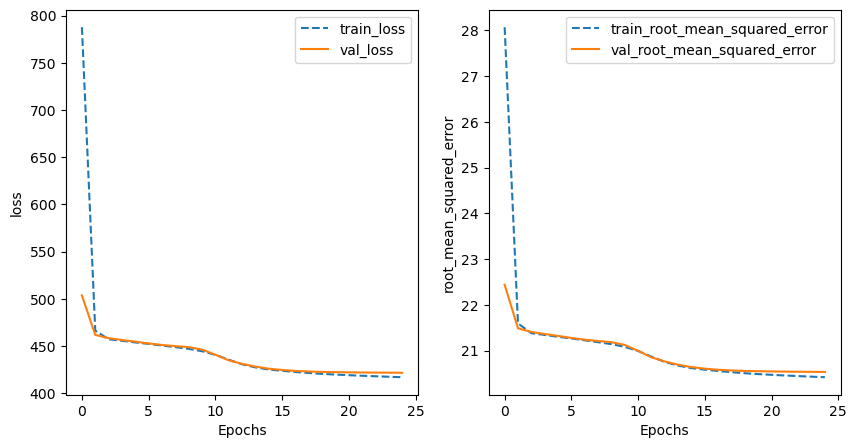

In [50]:
training_plot(['loss', 'root_mean_squared_error'], history)

In [51]:
sample_submission = pd.read_csv('/Users/wmeikle/Downloads/petfinder-pawpularity-score/sample_submission.csv')
sample_submission['Id'] = sample_submission['Id'].apply(lambda x: '../input/petfinder-pawpularity-score/test/'+x+'.jpg')
sample_submission.to_csv('sample_submission.csv', index=False, header=False)
sample_submission = tf.data.TextLineDataset(
    'sample_submission.csv'
).map(decode_csv).batch(BATCH_SIZE)

# Make predictions with our model
sample_prediction = model.predict(sample_submission)

# Format predictions to output for submission
submission_output = pd.concat(
    [pd.read_csv('../input/petfinder-pawpularity-score/sample_submission.csv').drop('Pawpularity', axis=1),
    pd.DataFrame(sample_prediction)],
    axis=1
)
submission_output.columns = [['Id', 'Pawpularity']]

# Output submission file to csv
submission_output.to_csv('submission.csv', index=False)

2025-09-12 23:29:22.252783: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at whole_file_read_ops.cc:116 : NOT_FOUND: ../input/petfinder-pawpularity-score/test/80bc3ccafcc51b66303c2c263aa38486.jpg; No such file or directory
2025-09-12 23:29:22.252944: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at whole_file_read_ops.cc:116 : NOT_FOUND: ../input/petfinder-pawpularity-score/test/b03f7041962238a7c9d6537e22f9b017.jpg; No such file or directory
2025-09-12 23:29:22.252952: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at whole_file_read_ops.cc:116 : NOT_FOUND: ../input/petfinder-pawpularity-score/test/4e429cead1848a298432a0acad014c9d.jpg; No such file or directory
2025-09-12 23:29:22.252958: W tensorflow/core/framework/op_kernel.cc:1840] OP_REQUIRES failed at whole_file_read_ops.cc:116 : NOT_FOUND: ../input/petfinder-pawpularity-score/test/4128bae22183829d2b5fea10effdb0c3.jpg; No such file or directory
2025-09-12 23:29:22.252977: 

NotFoundError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} ../input/petfinder-pawpularity-score/test/4128bae22183829d2b5fea10effdb0c3.jpg; No such file or directory
	 [[{{node ReadFile}}]] [Op:IteratorGetNext] name: 